## FULLY GENERATED AI MUSIC DETECTION

Reproducing experiments from **Section 4**, with slight variations likely due to different random states.

In [1]:
%matplotlib inline

import numpy as np
import pandas as pd
from IPython.display import display
import joblib
import matplotlib.pyplot as plt

from hybrid_detection.full_ai_exp.paths import FullAiExperimentPaths
from hybrid_detection.core.eval import tpr_fpr
from hybrid_detection.core.data.fakeprint import FakePrint


In [2]:
# Loading exp data
exp_paths = FullAiExperimentPaths()

# FMA
chunk_durs = [None, 10, 5, 2, 1]  # Global vs local detection, influence of chunk duration
fma_model_list = []
fma_pred_list = []

for chunk_dur in chunk_durs:
    model_dir = exp_paths.model_dir(db='fma', codec='encodec24', chunk_dur=chunk_dur)
    fma_model_list.append(joblib.load(f'{model_dir}/model.pkl'))
    fma_pred_list.append(pd.read_parquet(f'{model_dir}/train_test_predictions.parquet'))

fma_pred_df = pd.concat(fma_pred_list, ignore_index=True)
fma_pred_df['db'] = 'fma'
fma_pred_df = fma_pred_df[~fma_pred_df['train_set']]  # keep test set

# MUSDB vg_ag, vr_ar
# note: No ground-truth (binary label) for hybrid cases vg_ar, vr_ag
musdb_pred_dir = exp_paths.predictions_dir(db_predict='musdb_mixtures',db_train='fma', codec='encodec24', chunk_dur=None)
musdb_predictions_df = pd.read_parquet(musdb_pred_dir)
musdb_predictions_df['db'] = 'musdb_mixtures'
musdb_predictions_df['label'] = musdb_predictions_df['mix_type'] \
    .apply(lambda x: {'vr_ar': 0, 'vg_ag': 1}.get(x, None))


### Global and local binary detection evaluation
- Global: chunk_dur = NaN (_i.e._ from full audio length)
- Local: chunk_dur in [10, 5, 2, 1] s

Reproducing:
- **Training on fully generated music** paragraph eval
- **Table 2:** _Fully AI-generated chunk prediction performance as a function of the audio chunk duration (in seconds)._

In [3]:
print('\nFMA encodec24 test set detection perf: Table 2. Fully AI-generated chunk prediction performance as a function of the audio chunk duration (in seconds).')

fma_eval_df = fma_pred_df \
    .groupby(['db', 'chunk_dur'], dropna=False) \
    .apply(lambda x: tpr_fpr(x['label'], x['full_ai_score'], thr=0.5, as_pandas=True)) \
    .sort_index(ascending=False, na_position='first')

for metric in ['tpr', 'fpr']:
    fma_eval_df[metric] = np.round(100 * fma_eval_df[metric], 3)

display(fma_eval_df.transpose())

print('\nMUSDB encodec24 fully real and fully fake test set, global detection perf:')

musdb_eval_df = musdb_predictions_df[~musdb_predictions_df['label'].isna()] \
    .groupby(['db', 'chunk_dur'], dropna=False) \
    .apply(lambda x: pd.Series([set(x['mix_type'])] + tpr_fpr(x['label'], x['full_ai_score'], thr=0.5),
                               index=['mix_types', 'tpr', 'fpr'])) \
    .sort_index(ascending=False, na_position='first')

for metric in ['tpr', 'fpr']:
    musdb_eval_df[metric] = np.round(100 * musdb_eval_df[metric], 3)

display(musdb_eval_df.transpose())



FMA encodec24 test set detection perf: Table 2. Fully AI-generated chunk prediction performance as a function of the audio chunk duration (in seconds).


db            fma                                
chunk_dur    NaN     10.0    5.0     2.0     1.0 
tpr        99.858  99.861  99.841  99.291  97.162
fpr         0.014   0.051   0.164   0.476   1.814


MUSDB encodec24 fully real and fully fake test set, global detection perf:


db,musdb_mixtures
chunk_dur,NaN
mix_types,"{vr_ar, vg_ag}"
tpr,100.0
fpr,0.0


### Testing on hybrid mixtures

Reproducing **Table 1:** _Proportion (in %) of tracks detected as fully generated when the reference detector is directly applied to hybrid mixtures, for different mixing gains._

In [4]:
print('\nMUSDB encodec24 hybrid cases:\n'
      'Table 1. Proportion (in %) of tracks detected as fully generated when the reference\n'
      'detector is directly applied to hybrid mixtures, for different mixing gains.')

musdb_hybrid_eval_df = musdb_predictions_df[musdb_predictions_df['mix_type'].isin(['vr_ag', 'vg_ar'])] # keep hybrids
musdb_hybrid_eval_df['is_full_ai'] = musdb_hybrid_eval_df['full_ai_score'] >= 0.5
musdb_hybrid_eval_df['target_gain_db'] = musdb_hybrid_eval_df \
    .apply(lambda x: {'vg_ar': 1, 'vr_ag': -1}[x['mix_type']] * x['vocals_gain_db'], axis=1)

musdb_hybrid_eval_df = musdb_hybrid_eval_df \
    .groupby(['db', 'chunk_dur', 'target_gain_db', 'mix_type'], dropna=False) \
    .agg({'is_full_ai': 'mean'}) \
    .reset_index(drop=False)
musdb_hybrid_eval_df['is_full_ai'] = musdb_hybrid_eval_df['is_full_ai'].apply(lambda x: np.round(100*x, 2))

display(musdb_hybrid_eval_df.pivot(index=['db', 'chunk_dur', 'mix_type'], columns='target_gain_db', values='is_full_ai'))



MUSDB encodec24 hybrid cases:
Table 1. Proportion (in %) of tracks detected as fully generated when the reference
detector is directly applied to hybrid mixtures, for different mixing gains.


target_gain_db                       -12    -6       0       6       12
db             chunk_dur mix_type                                      
musdb_mixtures NaN       vg_ar     15.33  34.00   58.67   82.67   88.67
                         vr_ag     98.00  98.67  100.00  100.00  100.00

### Extra: Analyzing the detector's weights

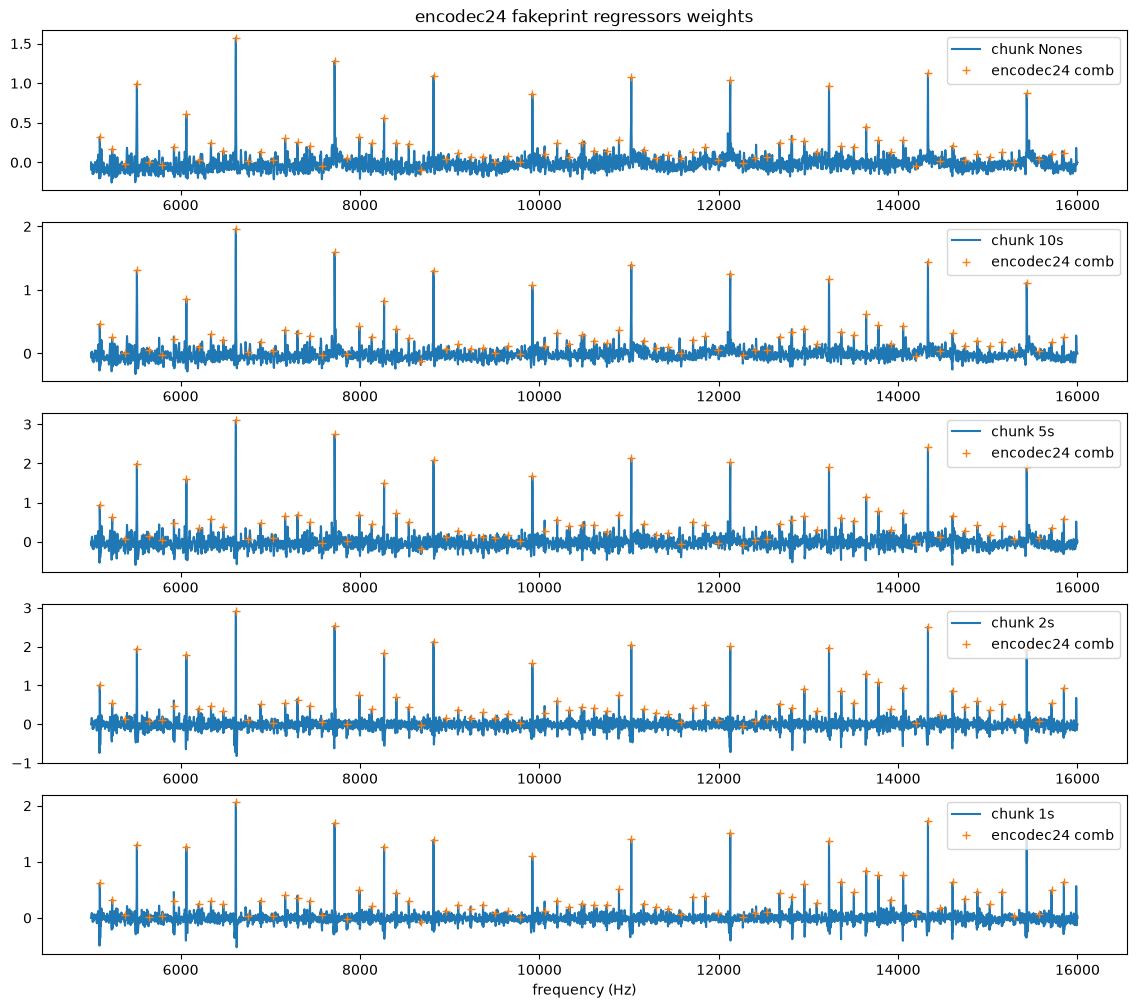

In [5]:
fakeprint = FakePrint()
f_axis = fakeprint.f_axis

# Build encodec24 expected artifacts profile, cf. D. Afchar, A Fourier Explanation fo AI-music Artifacts, ISMIR 2025
encodec_latent_sr = 150 # Hz
resampling_factor = 44100 / 48000  # cf. databases/neuralcodecs/encodec.py arg `sr_forced`from method `autoencode_from_files`
encodec_f0 = encodec_latent_sr * resampling_factor
# spectral replication while upsampling into successive decoder's layers
encodec_comb_Hz = np.arange(np.ceil(f_axis[0]/encodec_f0), np.floor(f_axis[-1]/encodec_f0)) * encodec_f0
encodec_comb_bins = np.argmin(np.abs(encodec_comb_Hz[:, None] - f_axis[None, :]), axis=1)

# Display model weights
fig, axes = plt.subplots(nrows=len(chunk_durs), ncols=1, figsize=(14, 12))
for model_id in range(len(fma_model_list)):
    axes[model_id].plot(f_axis, fma_model_list[model_id].coef_[0, :], label=f'chunk {chunk_durs[model_id]}s')
    axes[model_id].plot(f_axis[encodec_comb_bins], fma_model_list[model_id].coef_[0, encodec_comb_bins], '+', label=f'encodec24 comb')
    axes[model_id].legend()
axes[0].set_title('encodec24 fakeprint regressors weights')
axes[-1].set_xlabel('frequency (Hz)')
plt.show()